# GSAT waterfall by category and period, across scenarios (official-consistent input)

This reads `002_run_magicc_burden_based.py`'s output. Output files are prefixed `consistent_`.

## Imports

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
from pandas_openscm.db import FeatherDataBackend, FeatherIndexBackend, OpenSCMDB

import attribution_common as ac

## Configuration

In [2]:
EMBARGOED = True
"""Set True once running against real (embargoed) ScenarioMIP scenarios. Must match
02's own EMBARGOED setting."""
DATA_DIR = Path("../data/embargoed") if EMBARGOED else Path("../data")

BASE_SCENARIOS = ac.load_base_scenarios(DATA_DIR)
REGION = ac.REGION

BURDEN_SCM_OUTPUT_DB_DIR = DATA_DIR / "consistent_burden_scm_output_db"
"""Only needed here for the real total run's own GSAT, to compute the shared
assessment-matching shift each forcing channel's rebase now uses - see
`ac.rebase_gsat_channel_matrix`'s docstring."""
BURDEN_GSAT_DB_DIR = DATA_DIR / "consistent_burden_gsat_db"
"""002's output dir."""

PLOTS_DIR = Path("../data/plots")
"""Always plain data/plots/, regardless of EMBARGOED - plots are not considered
sensitive, only raw emissions/MAGICC output."""
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_PREFIX = "consistent_"
"""Prepended to every plot filename below."""

STACK_BUCKETS = {
    "CO2": ["CO2"],
    "CH4": ["CH4"],
    "N2O": ["N2O"],
    "Montreal Protocol Halogen Gases": ["Montreal Protocol Halogen Gases"],
    "F-Gases": ["F-Gases"],
    "Tropospheric Ozone": ["Tropospheric Ozone"],
  #  "Stratospheric H2O": ["Stratospheric H2O"],
    "Aerosols Direct Effect": ["Aerosol-Radiation Interactions"],
    "Aerosols Indirect Effect": ["Aerosol-Cloud Interactions"],
}

BUCKET_COLORS = {
    "CO2": "#707070",
    "CH4": "LightSkyBlue",
    "N2O": "orange",
    "Montreal Protocol Halogen Gases": "cyan",
    "F-Gases": "blue",
    "Tropospheric Ozone": "yellow",
  #  "Stratospheric H2O": "magenta",
    "Aerosols Direct Effect": "purple",
    "Aerosols Indirect Effect": "#B19CD9",
}

TIME_BLOCKS = [
    ("Historical", None, 2025),
    ("2025-2050", 2025, 2050),
    ("2050-2075", 2050, 2075),
    ("2075-2100", 2075, 2100),
    ("Total to 2100", None, 2100),
]
"""(label, start_year, end_year) - start_year=None means "absolute value at end_year"
(cumulative since 1750), otherwise "value at end_year minus value at start_year"."""
STAGE_LABELS = [label for label, _, _ in TIME_BLOCKS]
N_STAGES = len(TIME_BLOCKS)

CATEGORIES = list(STACK_BUCKETS.keys())

## Load shared data

In [3]:
burden_scm_output = OpenSCMDB(
    backend_data=FeatherDataBackend(), backend_index=FeatherIndexBackend(), db_dir=BURDEN_SCM_OUTPUT_DB_DIR
).load(out_columns_type=int)
burden_scm_output.columns.name = "year"

burden_gsat_by_channel = OpenSCMDB(
    backend_data=FeatherDataBackend(), backend_index=FeatherIndexBackend(), db_dir=BURDEN_GSAT_DB_DIR
).load(out_columns_type=int)
burden_gsat_by_channel.columns.name = "year"
burden_gsat_by_channel = burden_gsat_by_channel.loc[
    (burden_gsat_by_channel.index.get_level_values("variable") == "Surface Air Temperature Change")
    & (burden_gsat_by_channel.index.get_level_values("region") == REGION)
]


def _raw_total_gsat_matrix(base_scenario):
    mask = (
        (burden_scm_output.index.get_level_values("scenario") == base_scenario)
        & (burden_scm_output.index.get_level_values("variable") == "Surface Air Temperature Change")
        & (burden_scm_output.index.get_level_values("region") == REGION)
    )
    sub = burden_scm_output.loc[mask].reset_index().set_index("run_id")
    year_columns = [c for c in sub.columns if isinstance(c, int)]
    return sub[year_columns].sort_index()


def _raw_category_gsat_matrix(base_scenario, category):
    scenario = f"{base_scenario}_forcing_only_{category}"
    mask = burden_gsat_by_channel.index.get_level_values("scenario") == scenario
    sub = burden_gsat_by_channel.loc[mask].reset_index().set_index("run_id")
    year_columns = [c for c in sub.columns if isinstance(c, int)]
    return sub[year_columns].sort_index()


def category_gsat_matrix(base_scenario, category):
    """Rebased to the IPCC-standard 1850-1900 reference period. Shares
    `base_scenario`'s real total run's own assessment-matching shift
    (`ac.gsat_assessment_shift`) rather than independently recalibrating this one
    category to the full AR6-assessed 0.85K on its own ."""
    shift = ac.gsat_assessment_shift(_raw_total_gsat_matrix(base_scenario), n_channels=len(CATEGORIES))
    return ac.rebase_gsat_channel_matrix(_raw_category_gsat_matrix(base_scenario, category), shift)


def bucket_matrix(base_scenario, bucket):
    members = STACK_BUCKETS[bucket]
    return sum(category_gsat_matrix(base_scenario, c) for c in members)


def period_delta(matrix, start_year, end_year):
    """Member-level-first: per-member delta (or absolute value if start_year is None),
    *then* median - never the other way round."""
    return matrix[end_year] if start_year is None else (matrix[end_year] - matrix[start_year])


def stage_values(base_scenario, bucket):
    """Median per-member value at each of the 5 waterfall stages (Historical, 3 period
    deltas, Total). A waterfall bar is a single value, not a distribution - unlike most
    other plots in this project, this one deliberately skips uncertainty bands, given
    how dense the 7x10 grid already is."""
    matrix = bucket_matrix(base_scenario, bucket)
    return [period_delta(matrix, start, end).median() for _, start, end in TIME_BLOCKS]

## Waterfall drawing helpers

In [4]:
def waterfall_bar_spans(values):
    """Given the 5 stage values [Historical, D1, D2, D3, Total], return (bottom,
    height) for each of the 5 bars: Historical and Total are full bars from 0; the 3
    middle bars float from the running cumulative total so far to the running
    cumulative after this period's delta - exact by construction (Historical + D1 + D2
    + D3 = Total)."""
    historical, d1, d2, d3, total = values
    spans = [(0.0, historical)]
    running = historical
    for d in (d1, d2, d3):
        bottom = running if d >= 0 else running + d
        spans.append((bottom, abs(d)))
        running += d
    spans.append((0.0, total))
    return spans


def draw_single_waterfall(ax, values, color):
    historical, d1, d2, d3, _total = values
    spans = waterfall_bar_spans(values)
    for i, (bottom, height) in enumerate(spans):
        ax.bar(i, height, bottom=bottom, color=color, edgecolor="black", linewidth=0.5, width=0.65, zorder=3)

    cumulative_levels = [historical, historical + d1, historical + d1 + d2, historical + d1 + d2 + d3]
    for i, level in enumerate(cumulative_levels):
        ax.plot([i + 0.325, i + 1 - 0.325], [level, level], color=ac.COLOR_MUTED, linewidth=0.8, linestyle="--", zorder=2)

    ax.axhline(0, color=ac.COLOR_WARMING, linewidth=1.0, linestyle="--", zorder=4)


def stack_segments(vals_by_category, local_baseline):
    """Stack the 9 categories' own values at one stage: positives stacked upward from
    `local_baseline`, negatives stacked downward from that SAME `local_baseline` (in
    CATEGORIES' fixed order), rather than negatives continuing from the top of the positive 
    stack (which would paint over/occlude the top segment's color instead of showing a 
    separate below-baseline notch). The returned `new_baseline` is `local_baseline + net` 
    (net = sum of all 9 values) - not the edge of either stack - used only to position the
    *next* floating bar/connector line, per the waterfall's own running-total bookkeeping."""
    segments = []
    pos_top = local_baseline
    neg_bottom = local_baseline
    for c in CATEGORIES:
        v = vals_by_category[c]
        if v >= 0:
            segments.append((c, pos_top, v))
            pos_top += v
        else:
            segments.append((c, neg_bottom, v))
            neg_bottom += v
    new_baseline = local_baseline + sum(vals_by_category.values())
    return segments, new_baseline


def draw_stacked_waterfall(ax, stage_dicts):
    """`stage_dicts`: list of 5 dicts (one per waterfall stage), each
    dict[category -> that category's own value at this stage] - same per-category
    values used for the 9 rows above, just cross-sectioned by stage and stacked."""
    running = 0.0
    cumulative_levels = []
    for stage_idx in range(N_STAGES):
        is_endpoint_total = stage_idx == N_STAGES - 1
        local_baseline = 0.0 if (stage_idx == 0 or is_endpoint_total) else running
        segments, new_top = stack_segments(stage_dicts[stage_idx], local_baseline)
        for category, bottom, height in segments:
            ax.bar(
                stage_idx, height, bottom=bottom, color=BUCKET_COLORS[category], edgecolor="black",
                linewidth=0.4, width=0.65, zorder=3,
            )
        if not is_endpoint_total:
            running = new_top
            cumulative_levels.append(running)

    for i, level in enumerate(cumulative_levels):
        ax.plot([i + 0.325, i + 1 - 0.325], [level, level], color=ac.COLOR_MUTED, linewidth=0.8, linestyle="--", zorder=2)

    ax.axhline(0, color=ac.COLOR_WARMING, linewidth=1.0, linestyle="--", zorder=4)

## Compute per-(scenario, category) stage values

In [5]:
scenario_short_names = [ac.scenario_short_name(s) for s in BASE_SCENARIOS]
scenario_display_labels = [ac.scenario_display_label(s) for s in BASE_SCENARIOS]

stage_values_by_scenario_category = {
    (short_name, category): stage_values(base_scenario, category)
    for base_scenario, short_name in zip(BASE_SCENARIOS, scenario_short_names)
    for category in CATEGORIES
}

## Plot: 7 (scenario) x 10 (category + Total) waterfall grid, and a 7x9 version without the Total row

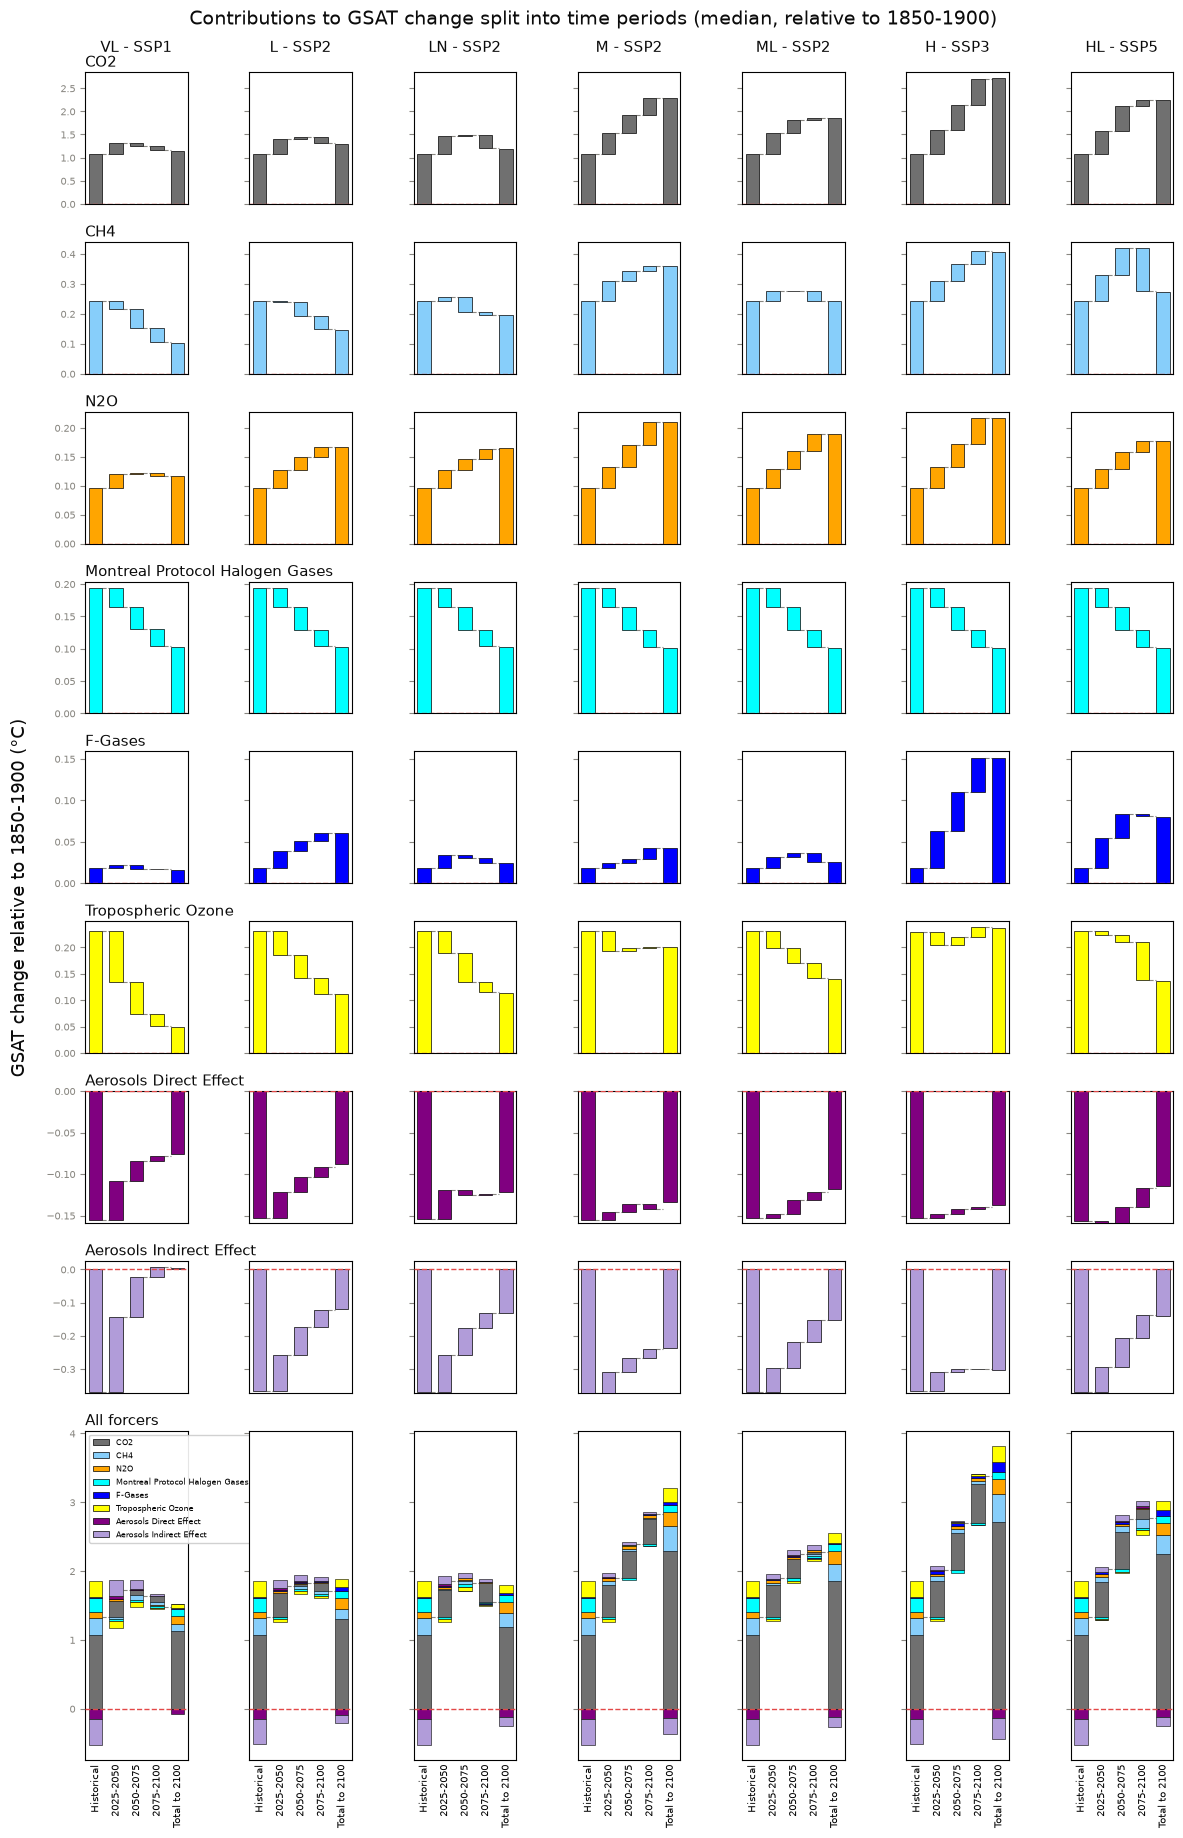

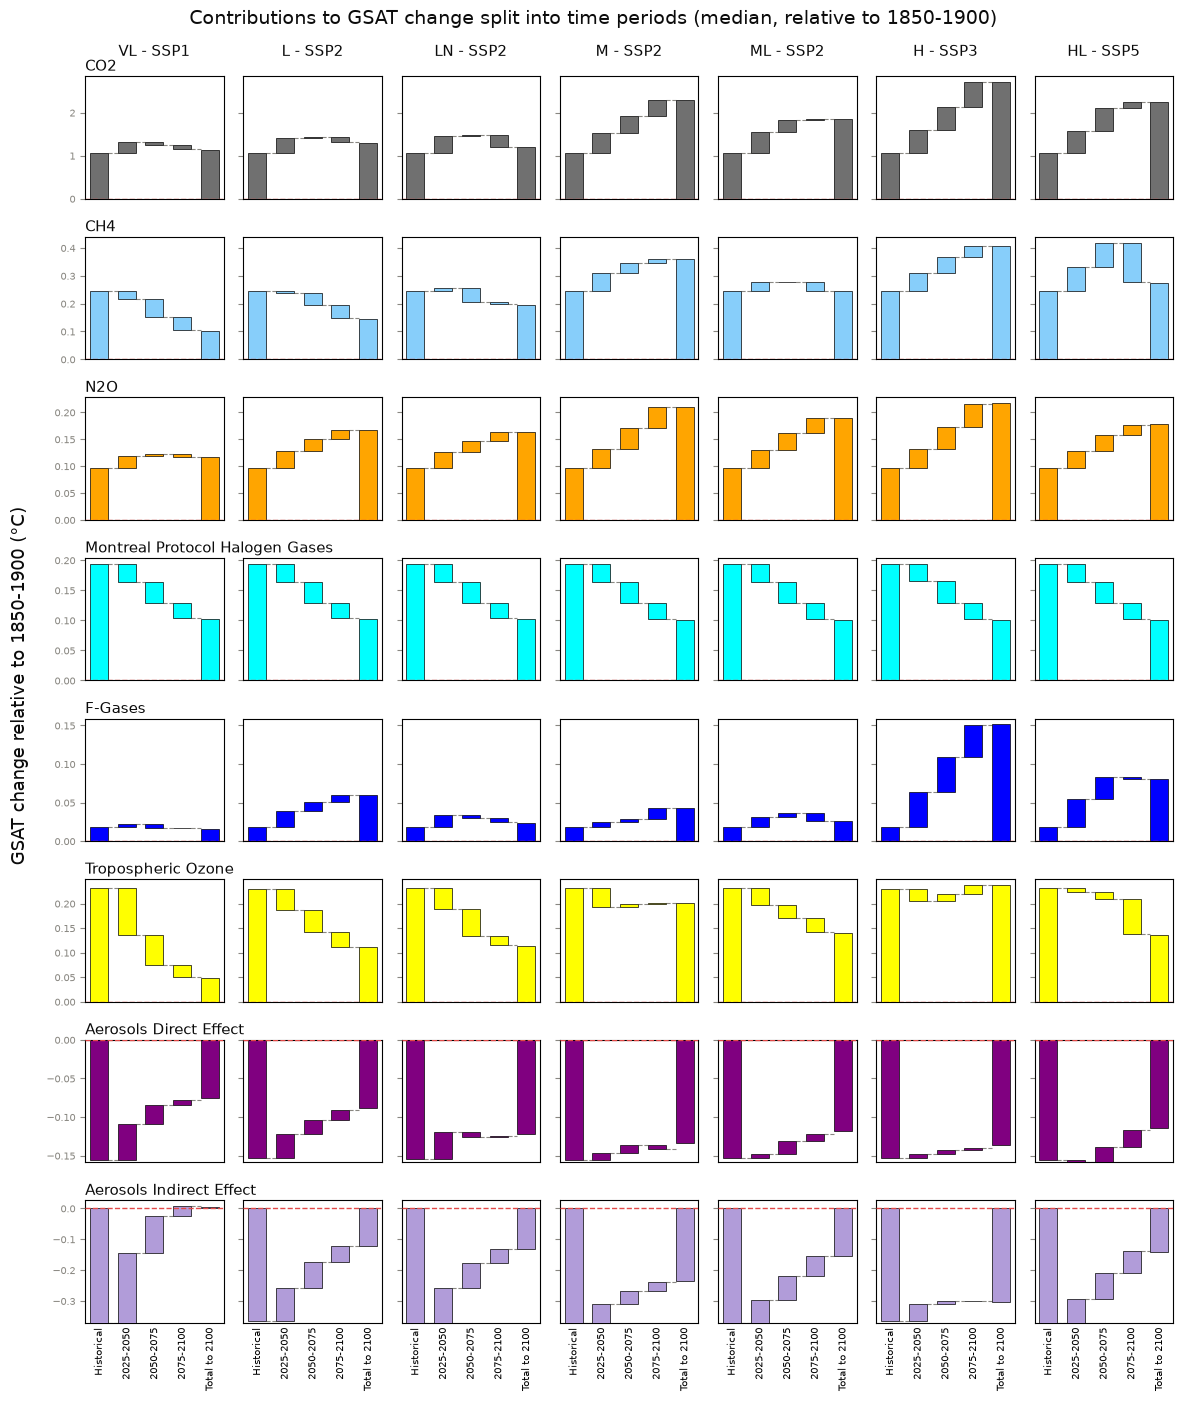

In [6]:
n_cols = len(BASE_SCENARIOS)
TOTAL_ROW_HEIGHT_RATIO = 2.5
"""The bottom "Total" row gets more vertical space than the 9 category rows above it -
it's the row most worth lingering on (the full stacked breakdown)."""


def make_grid_plot(include_total, out_path):
    n_rows = len(CATEGORIES) + (1 if include_total else 0)
    height_ratios = [1.0] * len(CATEGORIES) + ([TOTAL_ROW_HEIGHT_RATIO] if include_total else [])
    fig_height = 1.8 * (len(CATEGORIES) + (TOTAL_ROW_HEIGHT_RATIO if include_total else 0))

    fig, axes = plt.subplots(
        n_rows, n_cols, figsize=(1.7 * n_cols, fig_height),
        #n_rows, n_cols, figsize=(2.2 * n_cols, fig_height),
        facecolor=ac.COLOR_SURFACE, sharey="row", gridspec_kw={"height_ratios": height_ratios},
    )

    for row, category in enumerate(CATEGORIES):
        color = BUCKET_COLORS[category]
        for col, short_name in enumerate(scenario_short_names):
            ax = axes[row, col]
            ax.set_facecolor(ac.COLOR_SURFACE)
            values = stage_values_by_scenario_category[(short_name, category)]
            draw_single_waterfall(ax, values, color)

    if include_total:
        for col, short_name in enumerate(scenario_short_names):
            ax = axes[-1, col]
            ax.set_facecolor(ac.COLOR_SURFACE)
            stage_dicts = [
                {c: stage_values_by_scenario_category[(short_name, c)][stage_idx] for c in CATEGORIES}
                for stage_idx in range(N_STAGES)
            ]
            draw_stacked_waterfall(ax, stage_dicts)

    for col, display_label in enumerate(scenario_display_labels):
        # A plain `ax.set_title(..., pad=...)` would work for every column except col 0 -
        # matplotlib routes left/center/right titles through ONE shared offset transform
        # per axes (`_set_title_offset_trans`), reset on every `set_title()` call
        # regardless of `loc`, so whichever of the two `set_title` loops below touches
        # axes[0, 0] LAST would silently overwrite the other's `pad` for both texts on
        # that one shared axes. `annotate` sidesteps this entirely (its own independent
        # Text position), so its pad survives the category-label loop below.
        axes[0, col].annotate(
            display_label, xy=(0.5, 1), xycoords="axes fraction", xytext=(0, 12), textcoords="offset points",
            ha="center", va="bottom", fontsize=11, color=ac.COLOR_PRIMARY_TEXT,
        )

    row_labels = CATEGORIES + (["All forcers"] if include_total else [])
    for row, label in enumerate(row_labels):
        # `loc="left"` is independent of the centered scenario-name annotation row 0
        # already carries - this is a per-row label, not a per-panel one, so it's only
        # set on the leftmost column.
        axes[row, 0].set_title(label, loc="left", fontsize=10.5, color=ac.COLOR_PRIMARY_TEXT, pad=4)

    for row in range(n_rows):
        for col in range(n_cols):
            ax = axes[row, col]
            ax.set_xlim(-0.5, N_STAGES - 0.5)
            ax.set_xticks(range(N_STAGES))
            if row == n_rows - 1:
                ax.set_xticklabels(STAGE_LABELS, fontsize=7.5, rotation=90, ha="center")
            else:
                ax.set_xticklabels([])
            ax.tick_params(axis="y", labelsize=7.5, colors=ac.COLOR_MUTED)
            ax.tick_params(axis="x", length=0)
            # Full black box outline, matching this project's other bucket-colored bar
            # charts (e.g. `ac.plot_category_bars`'s bucket_colors mode) rather than the
            # lighter sign-colored default aesthetic.
            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_color("black")

    if include_total:
        # Without the Total row, this legend would be redundant - each category row
        # already pairs its own color with its own label directly (row label + bar
        # color), unlike the Total row's stacked mix of all 9 colors in one bar.
        legend_handles = [
            plt.Rectangle((0, 0), 1, 1, facecolor=BUCKET_COLORS[c], edgecolor="black", linewidth=0.5) for c in CATEGORIES
        ]
        axes[-1, 0].legend(legend_handles, CATEGORIES, loc="upper left", fontsize=6, frameon=True, framealpha=0.9)

    fig.suptitle(
        "Contributions to GSAT change split into time periods (median, relative to 1850-1900)",
        fontsize=14, color=ac.COLOR_PRIMARY_TEXT, y=0.97,
    )
    fig.supylabel(r"GSAT change relative to 1850-1900 (°C)", fontsize=13, color=ac.COLOR_PRIMARY_TEXT, x=0.01)

    fig.tight_layout(rect=(0, 0, 1, 0.98), w_pad=0.2)
    fig.savefig(out_path, dpi=150, facecolor=ac.COLOR_SURFACE, bbox_inches="tight")


make_grid_plot(include_total=True, out_path=PLOTS_DIR / f"{OUTPUT_PREFIX}waterfall_species_by_period_gsat.png")
make_grid_plot(include_total=False, out_path=PLOTS_DIR / f"{OUTPUT_PREFIX}waterfall_species_by_period_gsat_no_total.png")

# Export underlying data to CSV

Full quantile distributions (`stage_values` above only ever kept the median, one
value per waterfall bar) for every (scenario, category, stage) combination plotted -
the 9 `CATEGORIES` plus an "All forcers" row, computed member-level-first (sum the 9
category matrices per member, *then* take the period delta and quantiles - not
summed-after-quantiles) to match the "All forcers" row's own stacked-sum construction
in the plot above.

In [7]:
import pandas as pd

EXPORT_QUANTILES = [0.05, 0.10, 1 / 6, 0.33, 0.50, 0.67, 5 / 6, 0.90, 0.95]
"""Same 9-quantile convention used elsewhere in this project (e.g. the official
assessed-warming/ERF quantile CSVs, `repro_compare_erf_quantiles.py`)."""

export_rows = []
for base_scenario, short_name in zip(BASE_SCENARIOS, scenario_short_names):
    category_matrices = {c: bucket_matrix(base_scenario, c) for c in CATEGORIES}
    all_forcers_matrix = sum(category_matrices.values())
    for category, matrix in {**category_matrices, "All forcers": all_forcers_matrix}.items():
        for label, start_year, end_year in TIME_BLOCKS:
            delta = period_delta(matrix, start_year, end_year)
            for q in EXPORT_QUANTILES:
                export_rows.append(
                    {
                        "scenario": short_name,
                        "category": category,
                        "period": label.replace("\n", " "),
                        "quantile": q,
                        "value": delta.quantile(q),
                    }
                )

export_df = pd.DataFrame(export_rows)
export_csv_path = PLOTS_DIR / f"{OUTPUT_PREFIX}waterfall_species_by_period_gsat.csv"
export_df.to_csv(export_csv_path, index=False)
print(f"wrote {export_csv_path} ({len(export_df)} rows)")

wrote ../data/plots/consistent_waterfall_species_by_period_gsat.csv (2835 rows)
